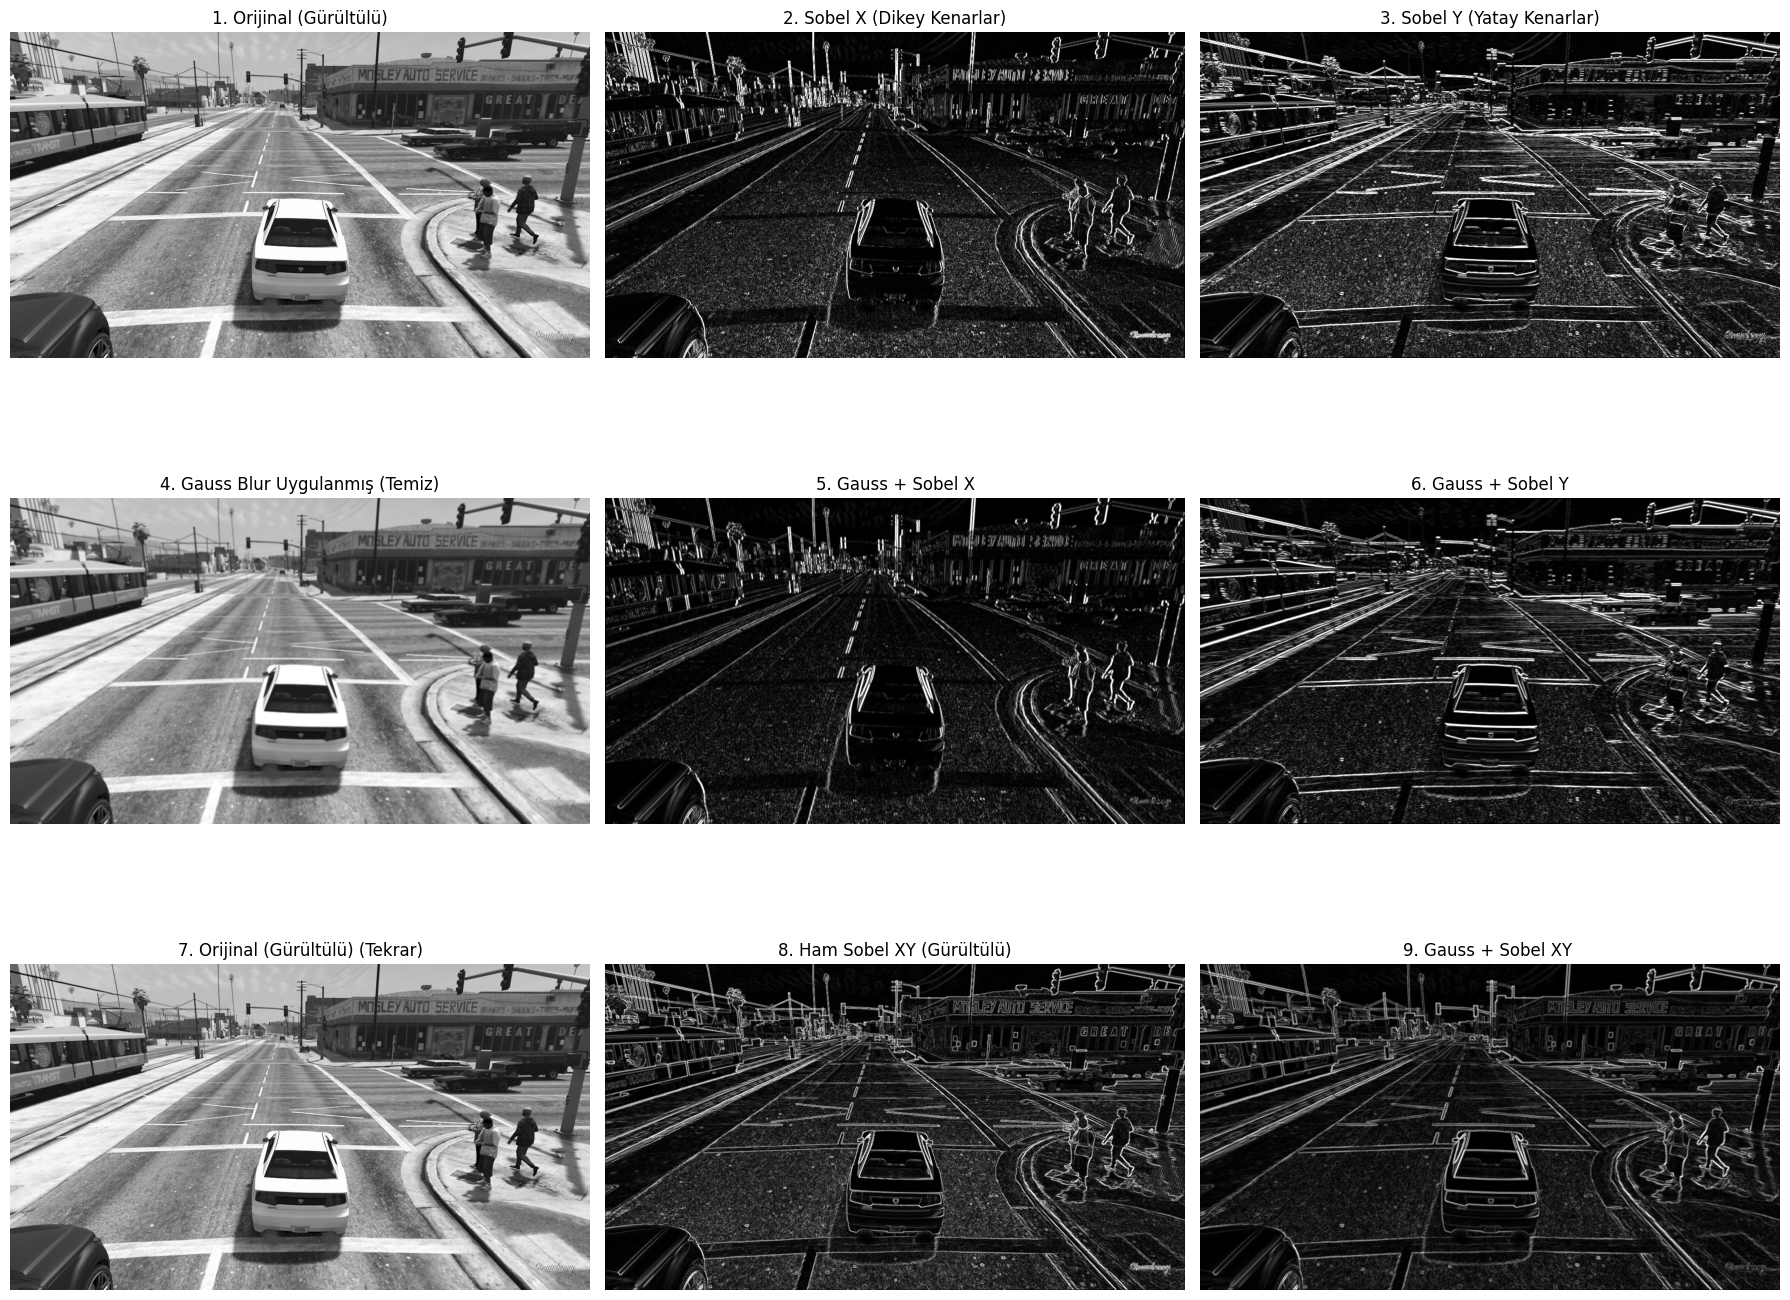

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- AŞAMA 1: GÖRÜNTÜYÜ OKU VE HAZIRLA ---
# Görüntüyü gri tonlamalı oku (Kenar tespiti için renk gerekmez)
img = cv2.imread('ornek_goruntu.png', cv2.IMREAD_GRAYSCALE)

# --- AŞAMA 2: TEMEL HESAPLAMALAR ---

# 2.1. Gauss Blur Uygulanmış Görüntü (Temizlik)
# (5, 5) kernel boyutu, gürültüyü yumuşatmak için idealdir.
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# --- AŞAMA 3: SOBEL OPERASYONLARI (X, Y, XY) ---

# 3.1. Orijinal Gürültülü Görüntüye Sobel (Ham Güç)
sobelx_raw = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3) # Sadece dikey kenarlar
sobely_raw = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3) # Sadece yatay kenarlar
sobelx_raw_8bit = cv2.convertScaleAbs(sobelx_raw) # Mutlak değer ve 8-bit'e sabitleme
sobely_raw_8bit = cv2.convertScaleAbs(sobely_raw)
# Ham Sobel X + Y (Gürültülü Tam Kenar Haritası)
sobelxy_raw_8bit = cv2.addWeighted(sobelx_raw_8bit, 0.5, sobely_raw_8bit, 0.5, 0)

# 3.2. Gauss Uygulanmış Görüntüye Sobel (Profesyonel Temizlik)
sobelx_blur = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3) # Temiz dikey kenarlar
sobely_blur = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3) # Temiz yatay kenarlar
sobelx_blur_8bit = cv2.convertScaleAbs(sobelx_blur) # Mutlak değer ve 8-bit'e sabitleme
sobely_blur_8bit = cv2.convertScaleAbs(sobely_blur)
# Gauss + Sobel X + Y (Jilet Gibi Temiz Tam Kenar Haritası)
sobelxy_blur_8bit = cv2.addWeighted(sobelx_blur_8bit, 0.5, sobely_blur_8bit, 0.5, 0)

# --- AŞAMA 4: 9'LU PANEL GÖRSELLEŞTİRME ---

plt.figure(figsize=(18, 15))

# --- BİRİNCİ SATIR: HAM GÖRÜNTÜ VE YÖNLÜ SOBEL ---
plt.subplot(3, 3, 1); plt.imshow(img, cmap='gray'); plt.title("1. Orijinal (Gürültülü)"); plt.axis('off')
plt.subplot(3, 3, 2); plt.imshow(sobelx_raw_8bit, cmap='gray'); plt.title("2. Sobel X (Dikey Kenarlar)"); plt.axis('off')
plt.subplot(3, 3, 3); plt.imshow(sobely_raw_8bit, cmap='gray'); plt.title("3. Sobel Y (Yatay Kenarlar)"); plt.axis('off')

# --- İKİNCİ SATIR: GAUSS TEMİZLİĞİ VE YÖNLÜ SOBEL ---
plt.subplot(3, 3, 4); plt.imshow(blurred, cmap='gray'); plt.title("4. Gauss Blur Uygulanmış (Temiz)"); plt.axis('off')
plt.subplot(3, 3, 5); plt.imshow(sobelx_blur_8bit, cmap='gray'); plt.title("5. Gauss + Sobel X"); plt.axis('off')
plt.subplot(3, 3, 6); plt.imshow(sobely_blur_8bit, cmap='gray'); plt.title("6. Gauss + Sobel Y"); plt.axis('off')

# --- ÜÇÜNCÜ SATIR: HAM VE TEMİZ SOBEL XY (BİRLEŞTİRİLMİŞ) ---
plt.subplot(3, 3, 7); plt.imshow(img, cmap='gray'); plt.title("7. Orijinal (Gürültülü) (Tekrar)"); plt.axis('off')
plt.subplot(3, 3, 8); plt.imshow(sobelxy_raw_8bit, cmap='gray'); plt.title("8. Ham Sobel XY (Gürültülü)"); plt.axis('off')
plt.subplot(3, 3, 9); plt.imshow(sobelxy_blur_8bit, cmap='gray'); plt.title("9. Gauss + Sobel XY "); plt.axis('off')

# Panelin yerleşimini sıkıştır
plt.tight_layout()
plt.show()